In [ ]:
import torch
from dit import DiT
from flow_matching import FlowModel
from dataset import *
from util import set_seed
from mel2wav import mel2wav
from frechet_audio_distance import FrechetAudioDistance


In [29]:
set_seed(9001)

n_frames = 512
n_test_examples = 10

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on", device)

dit = DiT(
    input_dim = 100, 
    num_heads = 4, 
    head_dim = 32, 
    n_blocks = 6,
    attn_pdrop = 0.1,
    causal = False,
    ff_scale = 2,
    cond_dim = None
)
model = FlowModel(dit, cfg_drop_prob=0.15)



ckpt_path = "mel_ckpt.pth"
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded checkpoint from {ckpt_path} (epoch {ckpt['epoch']}, step {ckpt['count']})")


model = model.to(device)
model.eval()



dataset = StarnetImageDataset(n_frames=n_frames)
train_set, test_set = torch.utils.data.random_split(dataset, [len(dataset) - n_test_examples, n_test_examples])

test_loader = DataLoader(
    test_set, 
    batch_size=n_test_examples, 
    # collate_fn=collate_trim
)

Running on cuda
Loaded checkpoint from mel_ckpt.pth (epoch 2999, step 9)


Reading in files: 100%|##########| 52/52 [00:07<00:00,  7.26it/s]


Done


In [30]:
import torch
from dit import DiT
from flow_matching import FlowModel
from dataset import *
from util import set_seed
from mel2wav import mel2wav
from frechet_audio_distance import FrechetAudioDistance




def eval(model, test_loader, dataset):
    set_seed(9001)
    with torch.no_grad():
        for _, (cond, target) in enumerate(test_loader):
            cond, target = cond.to(model.device), target.to(model.device)
            pred = model.sample(cond, steps=32, cfg_strength=3) * dataset.std + dataset.mu
            target = target * dataset.std + dataset.mu

            pred_wav = mel2wav(pred.transpose(-2, -1), out_fn=[f"model_eval/mel/pred/mel_pred_{i}.wav" for i in range(pred.shape[0])])
            tgt_wav = mel2wav(target.transpose(-2, -1), out_fn=[f"model_eval/mel/target/mel_target_{i}.wav" for i in range(target.shape[0])])

        fad = FrechetAudioDistance(
            model_name="vggish",
            sample_rate=16000,
            use_pca=False,
            use_activation=False,
        )

        fad_value = fad.score("./model_eval/mel/pred/", "./model_eval/mel/target/")
        print(f"FAD = {fad_value}")

        return fad_value

In [31]:
eval(model, test_loader, dataset)

Sampling flow model: 100%|██████████| 32/32 [00:00<00:00, 65.70it/s]
Using cache found in /home/yarnbowser/.cache/torch/hub/harritaylor_torchvggish_master


FAD = 9.71463990451806


9.714639904518061182

In [18]:
cond, target = next(iter(test_loader))  # (B, T, C)
cond   = cond.to(model.device)
target = target.to(model.device)

with torch.no_grad():
    pred_norm = model.sample(cond, steps=50, cfg_strength=0.5)  # (B, T, C) ?


print("target_norm mean/std:", target.mean().item(), target.std().item())
print("pred_norm   mean/std:", pred_norm.mean().item(), pred_norm.std().item())

pred   = pred_norm * dataset.std + dataset.mu
target_denorm = target * dataset.std + dataset.mu

print("target_denorm mean/std:", target_denorm.mean().item(), target_denorm.std().item())
print("pred_denorm   mean/std:", pred.mean().item(), pred.std().item())

Sampling flow model: 100%|██████████| 50/50 [00:06<00:00,  7.45it/s]


target_norm mean/std: -0.2144376039505005 0.9523782730102539
pred_norm   mean/std: -0.13067688047885895 0.9098507165908813
target_denorm mean/std: -8.895890235900879 2.6567022800445557
pred_denorm   mean/std: -8.662237167358398 2.5380699634552


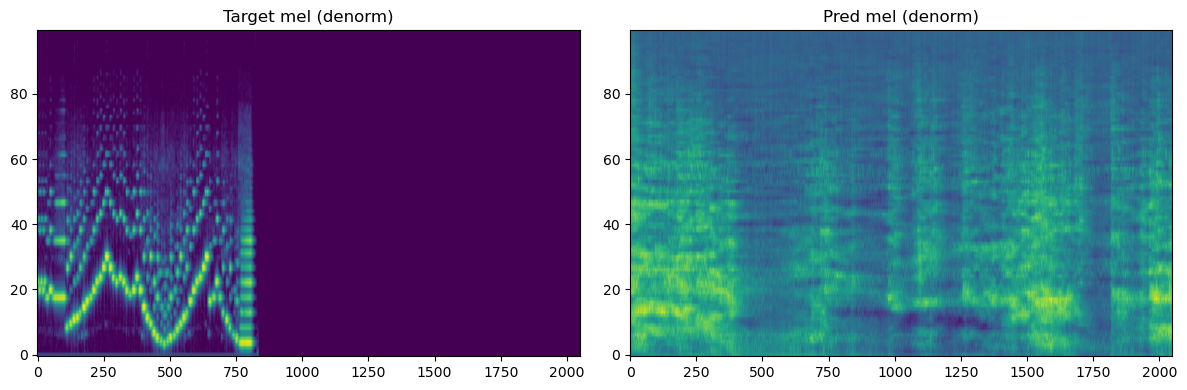

In [19]:
%matplotlib inline
import matplotlib.pyplot as plt

i = 0
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(target_denorm[i].cpu().T, aspect='auto', origin='lower')
plt.title("Target mel (denorm)")

plt.subplot(1,2,2)
plt.imshow(pred[i].detach().cpu().T, aspect='auto', origin='lower')
plt.title("Pred mel (denorm)")

plt.tight_layout()

In [5]:
cond1, target = next(iter(test_loader))
cond2, _      = next(iter(test_loader))

cond1 = cond1.to(model.device)
cond2 = cond2.to(model.device)

with torch.no_grad():
    pred1 = model.sample(cond1, steps=20, cfg_strength=3)  # or 0, see below
    pred2 = model.sample(cond2, steps=20, cfg_strength=3)

print("diff between preds:", (pred1 - pred2).abs().mean().item())

Sampling flow model: 100%|██████████| 20/20 [00:02<00:00,  7.19it/s]


diff between preds: 0.889241635799408
